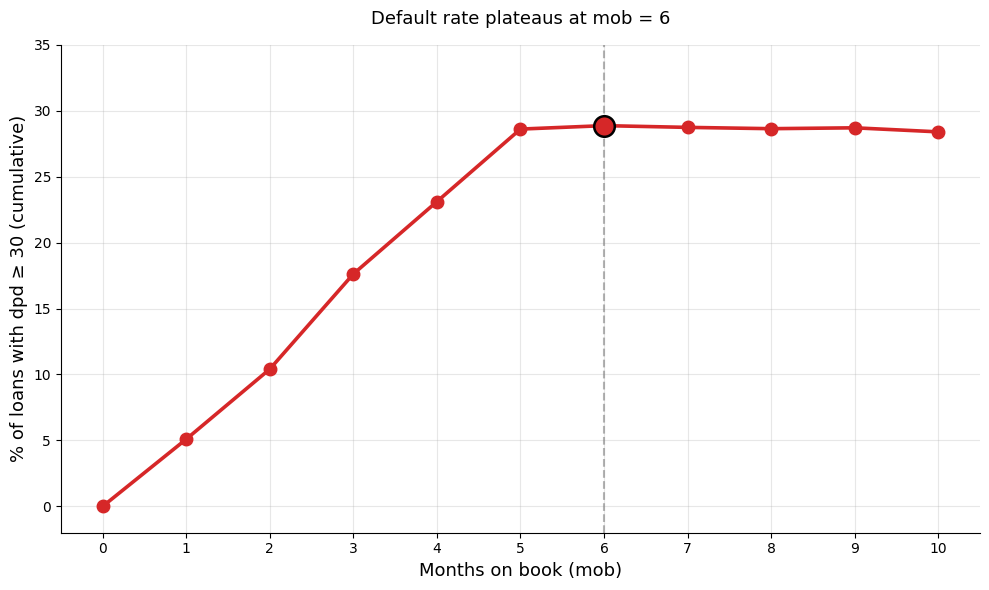

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pyspark

os.chdir("/app")
spark = pyspark.sql.SparkSession.builder.appName("plateau").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/app/datamart/silver/silver_loan_daily_*.parquet").toPandas()

rows = []
for m in sorted(df['mob'].dropna().unique()):
    sub = df[df['mob'] == m]
    rows.append({'mob': int(m), 'pct_dpd_ge_30': (sub['dpd'] >= 30).mean() * 100})
results = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results['mob'], results['pct_dpd_ge_30'],
        marker='o', linewidth=2.6, color='#d62728', markersize=9)

plateau_val = float(results.loc[results['mob'] == 6, 'pct_dpd_ge_30'].iloc[0])
ax.axvline(6, color='gray', linestyle='--', alpha=0.6)
ax.scatter([6], [plateau_val], s=220, color='#d62728', zorder=5, edgecolor='black', linewidth=1.8)

ax.set_xlabel('Months on book (mob)', fontsize=13)
ax.set_ylabel('% of loans with dpd ≥ 30 (cumulative)', fontsize=13)
ax.set_title('Default rate plateaus at mob = 6',
             fontsize=13, pad=15)
ax.set_xticks(range(0, int(results['mob'].max()) + 1))
ax.grid(True, alpha=0.3)
ax.set_ylim(-2, 35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/app/plateau_chart.png', dpi=200, bbox_inches='tight')
plt.show()



In [2]:
import os
import pyspark

os.chdir("/app")
spark = pyspark.sql.SparkSession.builder.appName("slide10").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/app/datamart/gold/training/gold_training_*.parquet")  # <-- glob, not directory

print(f"=== Training table summary ===")
print(f"Total rows : {df.count():,}")
print(f"Total cols : {len(df.columns)}")

print(f"\n=== Label distribution ===")
df.groupBy("label").count().orderBy("label").show()

print(f"\n=== One representative training row (features + label) ===")
df.select(
    "loan_id", "Customer_ID",
    "age_group", "debt_to_income", "emi_to_income",
    "credit_mix_score", "has_payday_loan",
    "is_overdue", "repayment_ratio", "clickstream_total",
    "label", "label_def"
).show(3, truncate=False, vertical=True)



=== Training table summary ===


Total rows : 8,974
Total cols : 67

=== Label distribution ===


+-----+-----+
|label|count|
+-----+-----+
|    0| 6383|
|    1| 2591|
+-----+-----+


=== One representative training row (features + label) ===
-RECORD 0----------------------------------
 loan_id           | CUS_0x8e8_2024_03_01  
 Customer_ID       | CUS_0x8e8             
 age_group         | 26-35                 
 debt_to_income    | 0.025754230566892352  
 emi_to_income     | 0.008715500109354705  
 credit_mix_score  | 1                     
 has_payday_loan   | 0                     
 is_overdue        | 0                     
 repayment_ratio   | NULL                  
 clickstream_total | 2176                  
 label             | 0                     
 label_def         | 30dpd_6mob            
-RECORD 1----------------------------------
 loan_id           | CUS_0x8ea_2024_03_01  
 Customer_ID       | CUS_0x8ea             
 age_group         | 26-35                 
 debt_to_income    | 0.16620357961651128   
 emi_to_income     | 0.03483399271493797   
 credit_mix_score  

In [3]:
import pyspark

spark = pyspark.sql.SparkSession.builder.appName("check").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

# load the training table
df = spark.read.parquet("/app/datamart/gold/training/gold_training_*.parquet")

# 1. basic counts
print("rows:", df.count())
print("columns:", len(df.columns))

# 2. label distribution
df.groupBy("label").count().show()

# 3. sample row
df.select("loan_id", "label", "age_group", "debt_to_income", "emi_to_income",
          "credit_mix_score", "has_payday_loan", "is_overdue",
          "repayment_ratio", "clickstream_total").show(5)


rows: 8974
columns: 67
+-----+-----+
|label|count|
+-----+-----+
|    1| 2591|
|    0| 6383|
+-----+-----+

+--------------------+-----+---------+--------------------+--------------------+----------------+---------------+----------+---------------+-----------------+
|             loan_id|label|age_group|      debt_to_income|       emi_to_income|credit_mix_score|has_payday_loan|is_overdue|repayment_ratio|clickstream_total|
+--------------------+-----+---------+--------------------+--------------------+----------------+---------------+----------+---------------+-----------------+
|CUS_0x8e8_2024_03_01|    0|    26-35|0.025754230566892352|0.008715500109354705|               1|              0|         0|           NULL|             2176|
|CUS_0x8ea_2024_03_01|    0|    26-35| 0.16620357961651128| 0.03483399271493797|            NULL|              0|         0|           NULL|             1474|
|CUS_0x8ebd_2024_0...|    0|    26-35|  0.2383661016659255| 0.03732321477183123|               0|

In [ ]:
s